In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score, precision_score, f1_score
import joblib
import seaborn as sns
import matplotlib.pyplot as plt

print("Loading ML-Ready Data...")
df = pd.read_csv("../data/processed/Hela_ML_Ready.csv")

# STEP 1: ENCODING & FIXING DATA LEAKAGE
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Encoding Categorical Columns: {categorical_cols}")
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# THE FIX: Drop 'Service_Years_Numeric' so the AI can't cheat!
# We also drop the target column 'Early_Attrition' to isolate the features (X).
columns_to_drop = ['Early_Attrition', 'Service_Years_Numeric']

X = df_encoded.drop(columns=columns_to_drop)
y = df_encoded['Early_Attrition']
display(X.head())

print(f"Data Leakage Prevented. Features ready: {len(X.columns)} columns.")

Loading ML-Ready Data...
Encoding Categorical Columns: ['Level', 'Designation', 'Grade', 'Team', 'Race', 'Gender', 'Marial Status', 'Transport mode', 'District']


,Age_At_Hiring,Level_Executive,Level_Manager,Level_Worker,Level_staff,Designation_Assistant - Administration,Designation_Assistant - CAD,Designation_Assistant - Engineering and Maintenance,Designation_Assistant - Human Resources,Designation_Assistant - Lean,...,District_Matale,District_Matara,District_Monaragala,District_Mullaitivu,District_Nuwara Eliya,District_Polonnaruwa,District_Puttalam,District_Ratnapura,District_Trincomalee,District_Vavuniya
0,27.25,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,19.33,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,25.59,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,55.91,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,36.50,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


Data Leakage Prevented. Features ready: 247 columns.


In [7]:
# STEP 2: THE TRAIN / TEST SPLIT
# 80% for training, 20% for testing. 
# random_state=42 ensures we get the exact same split every time we run the code.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print(f"\nData Split: {len(X_train)} Training rows, {len(X_test)} Testing rows.")

# Scale the numerical features (Important for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Data Split: 3940 Training rows, 986 Testing rows.


In [9]:
# STEP 3: THE ALGORITHM SHOWDOWN
print("\nInitiating Model Comparison \n")

# Define the 4 models we want to test
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

# Dictionary to store the results
results = []

for model_name, model in models.items():
    # Train the model (Use scaled data for Logistic Regression)
    if model_name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
    # Calculate Metrics for Class 1 (Leavers)
    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred) # How many leavers did we catch?
    prec = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append({
        "Model": model_name,
        "Accuracy": round(acc, 4),
        "Recall (Class 1)": round(rec, 4),
        "Precision (Class 1)": round(prec, 4),
        "F1-Score": round(f1, 4)
    })
    print(f"Trained: {model_name}")


Initiating Model Comparison 

Trained: Logistic Regression
Trained: Decision Tree
Trained: Random Forest
Trained: Gradient Boosting



📊 FINAL MODEL COMPARISON TABLE:
              Model  Accuracy  Recall (Class 1)  Precision (Class 1)  F1-Score
Logistic Regression    0.8692            0.8986               0.8487    0.8729
      Decision Tree    0.8286            0.8053               0.8447    0.8245
      Random Forest    0.8651            0.8844               0.8516    0.8677
  Gradient Boosting    0.8813            0.9168               0.8561    0.8854


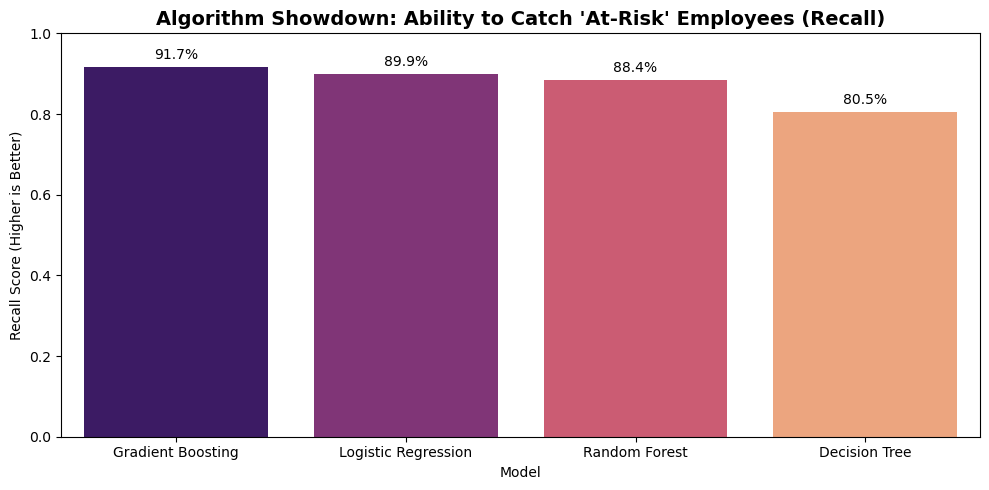

In [10]:
# STEP 4: VISUALIZING THE COMPARISON
results_df = pd.DataFrame(results)
print("\n📊 FINAL MODEL COMPARISON TABLE:")
print(results_df.to_string(index=False))

# Plot the comparison (This goes directly into your presentation!)
plt.figure(figsize=(10, 5))
# We sort by Recall because catching leavers is the most important metric
results_df_sorted = results_df.sort_values(by="Recall (Class 1)", ascending=False)

sns.barplot(data=results_df_sorted, x='Model', y='Recall (Class 1)', hue='Model', legend=False, palette='magma')
plt.title("Algorithm Showdown: Ability to Catch 'At-Risk' Employees (Recall)", fontsize=14, fontweight='bold')
plt.ylabel("Recall Score (Higher is Better)")
plt.ylim(0, 1.0)

# Add the numbers on top of the bars
for index, row in enumerate(results_df_sorted.iterrows()):
    plt.text(index, row[1]['Recall (Class 1)'] + 0.02, f"{row[1]['Recall (Class 1)']*100:.1f}%", color='black', ha="center")

plt.tight_layout()
plt.show()

In [11]:
# STEP 5: HYPERPARAMETER TUNING & CROSS-VALIDATION
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
print("\nInitiating Hyperparameter Tuning & Stability Check for Random Forest...")

# 1. Define the "Settings" to test (The Parameter Grid)
param_grid = {
    'n_estimators': [100, 200, 300, 500],     # Number of trees in the forest
    'max_depth': [None, 10, 20, 30],          # Maximum depth of the trees (prevents overfitting)
    'min_samples_split': [2, 5, 10],          # Min samples required to split an internal node
    'min_samples_leaf': [1, 2, 4],            # Min samples required to be at a leaf node
    'class_weight': ['balanced', 'balanced_subsample'] # Handling our slight class nuances
}

# 2. Define the Stability Mechanism (5-Fold Stratified Cross-Validation)
cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. Setup the Search (Optimizing specifically for 'recall')
rf_base = RandomForestClassifier(random_state=42)
rf_tuned = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_grid,
    n_iter=20,          # Test 20 random combinations (efficient and fast)
    cv=cv_strat,        # Use our 5-fold cross-validation
    scoring='recall',   # The business priority metric!
    n_jobs=-1,          # Use all of your computer's CPU cores to run faster
    random_state=42
)

# 4. Run the tuning
print("Training 5 folds across 20 combinations (100 total fits)... Please wait.")
rf_tuned.fit(X_train, y_train)
print("\nTuning Complete!")
print(f"Best Parameters Found: {rf_tuned.best_params_}")
print(f"Cross-Validated Recall Score: {round(rf_tuned.best_score_ * 100, 2)}%")

# 5. Extract the Winning Model
best_rf_model = rf_tuned.best_estimator_
# Let's test this newly tuned model on our hidden 20% test set
y_pred_tuned = best_rf_model.predict(X_test)
print("\nTuned Model Performance on Unseen Test Data:")
print(f"Accuracy:  {round(accuracy_score(y_test, y_pred_tuned), 4)}")
print(f"Recall:    {round(recall_score(y_test, y_pred_tuned), 4)}")
print(f"Precision: {round(precision_score(y_test, y_pred_tuned), 4)}")
print(f"F1-Score:  {round(f1_score(y_test, y_pred_tuned), 4)}")


Initiating Hyperparameter Tuning & Stability Check for Random Forest...
Training 5 folds across 20 combinations (100 total fits)... Please wait.

Tuning Complete!
Best Parameters Found: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 10, 'class_weight': 'balanced_subsample'}
Cross-Validated Recall Score: 95.64%

Tuned Model Performance on Unseen Test Data:
Accuracy:  0.8519
Recall:    0.9615
Precision: 0.7887
F1-Score:  0.8665


In [14]:
# STEP 6: SAVE THE BEST MODEL

# We save Random Forest (or whichever you prefer) as the final production model
# final_model = models["Random Forest"]
# joblib.dump(final_model, '../models/rf_churn_model.pkl')
# joblib.dump(list(X.columns), '../models/model_columns.pkl')
# joblib.dump(scaler, '../models/scaler.pkl') # Save scaler just in case we need it later

# print("\nModel Comparison Complete! Final Random Forest model saved to '../models/rf_churn_model.pkl'")
# STEP 5: SAVE THE BEST MODEL
joblib.dump(best_rf_model, '../models/rf_churn_model.pkl')
joblib.dump(list(X.columns), '../models/model_columns.pkl')

print("\ SUCCESS! Tuned & Validated Random Forest model saved to '../models/rf_churn_model.pkl'")

\ SUCCESS! Tuned & Validated Random Forest model saved to '../models/rf_churn_model.pkl'
